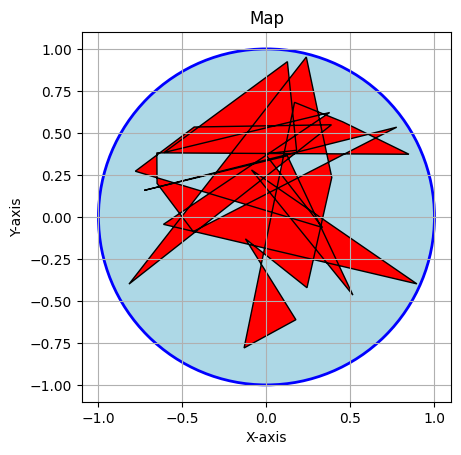

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import numpy as np


#MATPLOT LIB
# Create a figure and an axes
fig, ax = plt.subplots(1)

# Create a circle patch
circle = patches.Circle((0, 0), radius=1.0, fc='lightblue', ec='blue', linewidth=2)
ax.add_patch(circle)

# circle
ax.set_aspect('equal', adjustable='box')

# Plot scale
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])

# Path
points = []
for i in range(30):
  candidate = (np.random.uniform(-1, 1), np.random.uniform(-1, 1))
  while candidate[0]**2 + candidate[1]**2 >= 1:
    candidate = (np.random.uniform(-1, 1), np.random.uniform(-1, 1))
  points.append(candidate)

#Patch from path
patchPath = path.Path(points, closed = True).cleaned(curves=True)
splat = patches.PathPatch(path=patchPath, facecolor='red')
ax.add_patch(splat)

ax.set_title('Map')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')

plt.grid(True)
plt.show()

In [ ]:
#Perlin noise
import noise

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import numpy as np
from shapely.geometry import Polygon, Point, LineString
from shapely.ops import unary_union

segments = 64 #line segments per quarter circle

RNG = np.random.default_rng(7)

def make_map(r = 1.0):
  return Point(0.0,0.0).buffer(r, quad_segs=segments)

def make_splat(domain, rng, n_wobble = 7, step = 0.22, wobble_scale = 0.28, smooth = 0.05):
  R = np.sqrt(domain.area / np.pi)
  center = [0.0, 0.0]
  pos = center + rng.normal(scale = 0.25 * R, size = 2)

  wobbles = []
  for w in range(n_wobble):
    r = wobble_scale * R * rng.uniform(0.6, 1.4)
    wobbles.append(Point(pos).buffer(r, quad_segs=segments))
    pos = pos + rng.normal(scale = step * R, size = 2)

  splat = unary_union(wobbles)

  splat = splat.buffer(smooth * R, quad_segs = segments).buffer(-smooth * R, quad_segs = segments)


  splat = splat.intersection(domain)

  return splat

def make_sun_constraint(r = 0.5):
  return Point(0.0,0.0).buffer(r, quad_segs=segments)

In [9]:
def make_sweep(angle, offset, width, domain):
  R = np.sqrt(domain.area / np.pi)
  # along track
  d = np.array([np.cos(angle), np.sin(angle)])
  #across track
  n = np.array([-np.sin(angle), np.cos(angle)])

  p0 = (offset * n) - (2 *R * d)
  p1 = (offset * n) + (2 *R * d)
  track = LineString([p0, p1])

  return track.buffer(width / 2.0, cap_style=2).intersection(domain)


In [22]:
def make_patches(ax, geom, **kw):
    if geom.geom_type.startswith("Multi"):
      geoms = geom.geoms
    else:
      geoms = [geom]
    for g in geoms:
        if g.is_empty:
            continue
        ax.add_patch(patches.Polygon(np.array(g.exterior.coords), **kw))
        for ring in g.interiors:
            ax.add_patch(patches.Polygon(np.array(ring.coords), facecolor="white", edgecolor="none"))

def plot_scene(domain, splat, sweep, coverage, sun_constraint, overlap, path = "plot.png"):
  fig, ax = plt.subplots(figsize=(6.5, 6.5))

  make_patches(ax, domain, facecolor="#C4D8E2", edgecolor="black", linewidth=1.2)
  make_patches(ax, sun_constraint, facecolor="#FFDE21", edgecolor="#800000", linewidth=0.5)
  make_patches(ax, splat, facecolor="#50C878", edgecolor="#2C5F34", linewidth=1.5, alpha=0.8)
  make_patches(ax, coverage, facecolor="green", edgecolor="green", linewidth=1.5, alpha=0.8)
  make_patches(ax, overlap, facecolor="#F88379", edgecolor="#800000", linewidth=1.5, alpha=0.8)
  make_patches(ax, sweep, facecolor="#2b6cb0", edgecolor="none", alpha=0.30)


  R = np.sqrt(domain.area / np.pi)
  ax.set_xlim(-1.1 * R, 1.1 * R)
  ax.set_ylim(-1.1 * R, 1.1 * R)
  ax.set_aspect("equal")
  ax.axis("off")

  fig.savefig(path, dpi=150, bbox_inches="tight")
  plt.show()
  return path

In [ ]:
def coverage_report(splat, sweeps, constraints, domain):
  union = unary_union(sweeps)
  constraint = unary_union(constraints)
  coverage = union.intersection(splat)
  report = {
      "splat_area": splat.area,
      "domain_area": coverage.area,
      "coverage_fraction": coverage.area / splat.area
  }
  }

0.6017210215423496


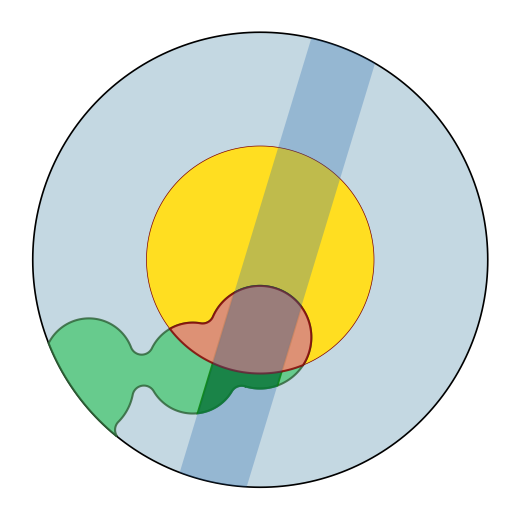

'plot.png'

In [33]:
domain = make_map(1.0)

splat = make_splat(domain, RNG)
#splat2 = make_splat(domain, RNG)
#splat = splat.union(splat2)

sun_constraint = make_sun_constraint(0.5)

rand_angle = RNG.uniform(0, 180)
rand_offset = RNG.uniform(-0.5, 0.5)
sweep = make_sweep(np.deg2rad(rand_angle), rand_offset, 0.3, domain)
overlap = splat.intersection(sweep)

sun_overlap = splat.intersection(sun_constraint)

print(overlap.area / (splat.area - sun_overlap.area))

plot_scene(domain, splat, sweep, overlap, sun_constraint, sun_overlap)